In [1]:
import os

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import biosppy as bio
import scipy.fftpack
import scipy as sc

from pathlib import Path

import sys
sys.path.append('../')

# physionet functions
from driver import load_challenge_data
from driver import get_classes
from get_12ECG_features import detect_peaks

In [2]:
base_path = Path('../')

input_path = base_path.joinpath('input_directory')

print(input_path.absolute())

C:\Users\riehlmn\PycharmProjects\physionet\physionet2020\notebooks\..\input_directory


In [3]:
# copied from driver.py for data import
input_files = []
for f in os.listdir(input_path.absolute()):
    if os.path.isfile(os.path.join(str(input_path), f)) \
        and not f.lower().startswith('.') and f.lower().endswith('mat'):
        input_files.append(f)

datas = []
headers = []
for file in input_files:
    data, header = load_challenge_data(str(input_path.joinpath(file)))
    datas.append(data)
    headers.append(header)

In [4]:
# get data with only one label
labels = []
one_label_datas = []
fq = int(headers[0][0].split(' ')[2]) # sample frequency is the same for all recordings
for i, file in enumerate(headers):
    dxs = []
    for line in file:
        if line.startswith('#Dx'):
            tmp = line.split(': ')[1].split(',')
            for dx in tmp:
                dxs.append(dx.strip())
    if len(dxs) == 1:
        labels.append(dxs[0])
        one_label_datas.append(datas[i])

In [5]:
# seperate single label data by classes
classes = get_classes(input_path.absolute(), input_files)
one_label_data_dict = {key: [] for key in classes}
for idx in range(len(one_label_datas)):
    one_label_data_dict[labels[idx]].append(one_label_datas[idx])

# Normal Sinus Rythm
- PQ-Interval (commonly PR-Interval in engl. literature)(beginning of P-Wave to beginning of Q-Wave) < 200 ms (if multiple leasds available: earliest beginning to latest beginning of Q-Wave)
- prolongation of PQ-Interval can be caused by medication
- QRS-Complex ~ 80 ms ( < 110 ms for adults)
- OT-Interval(beginning of Q-Wave to end of T-Wave) 30-400 ms (depends on heart rate)
- P-Wave negative in aVR
- T-Wave: positive QRS-Complex -> positive T-Wave: I - III, aVL, aVF, V2 - V6 positive; aVR negative; V1 p, n or biphasic
- amplitude of T-Wave can be up to 25% of R-Peak

## Einthoven

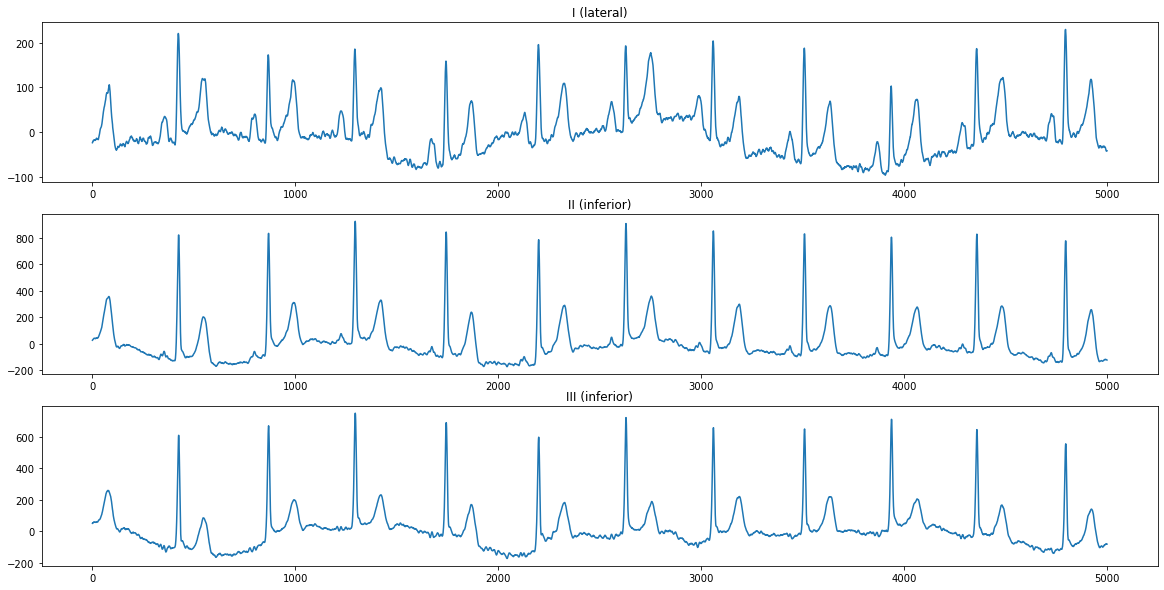

In [6]:
lead_names = ['I (lateral)', 'II (inferior)', 'III (inferior)', 'aVR', 'aVL (lateral)', 'aVF (inferior)', 'V1 (septal)', 'V2 (septal)', 'V3 (anterior)', 'V4 (anterior)', 'V5 (lateral)', 'V6 (lateral)']
fig = plt.figure(figsize=(20, 10))
for i in range(3): #3
    ax = fig.add_subplot(3, 1, i + 1)
    ax.plot(one_label_data_dict['Normal'][300][i][:5000])
    plt.title(lead_names[i])

plt.plot()
plt.show()    

## Goldberger

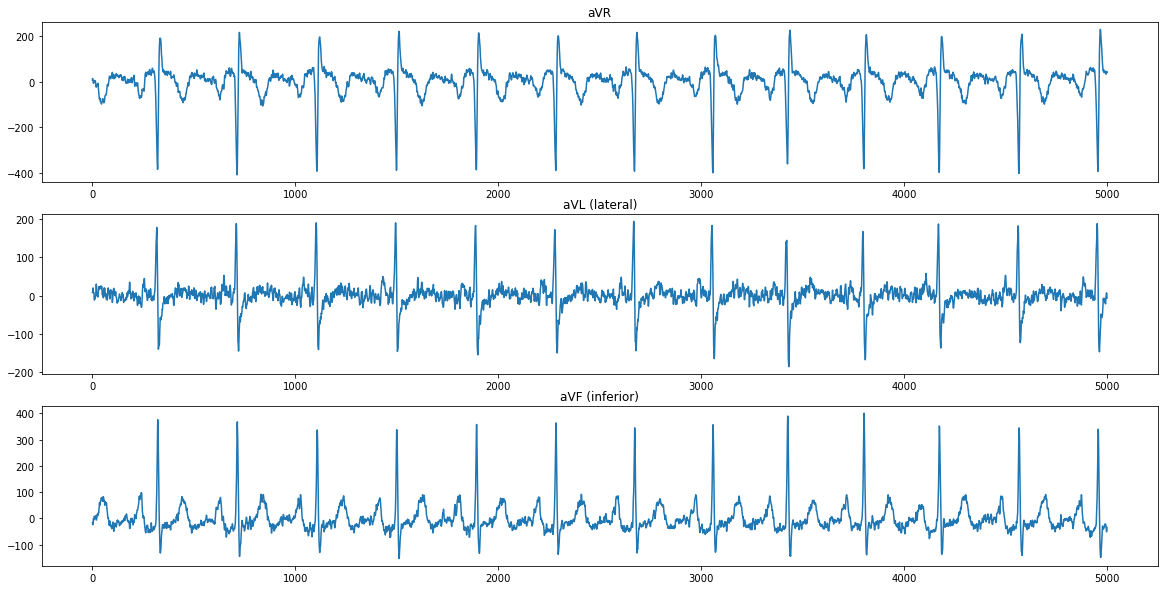

In [7]:
fig = plt.figure(figsize=(20, 10))
for i in range(3,6):
    ax = fig.add_subplot(3, 1, i - 2)
    ax.plot(one_label_data_dict['Normal'][0][i])
    plt.title(lead_names[i])

plt.plot()
plt.show()

## Wilson

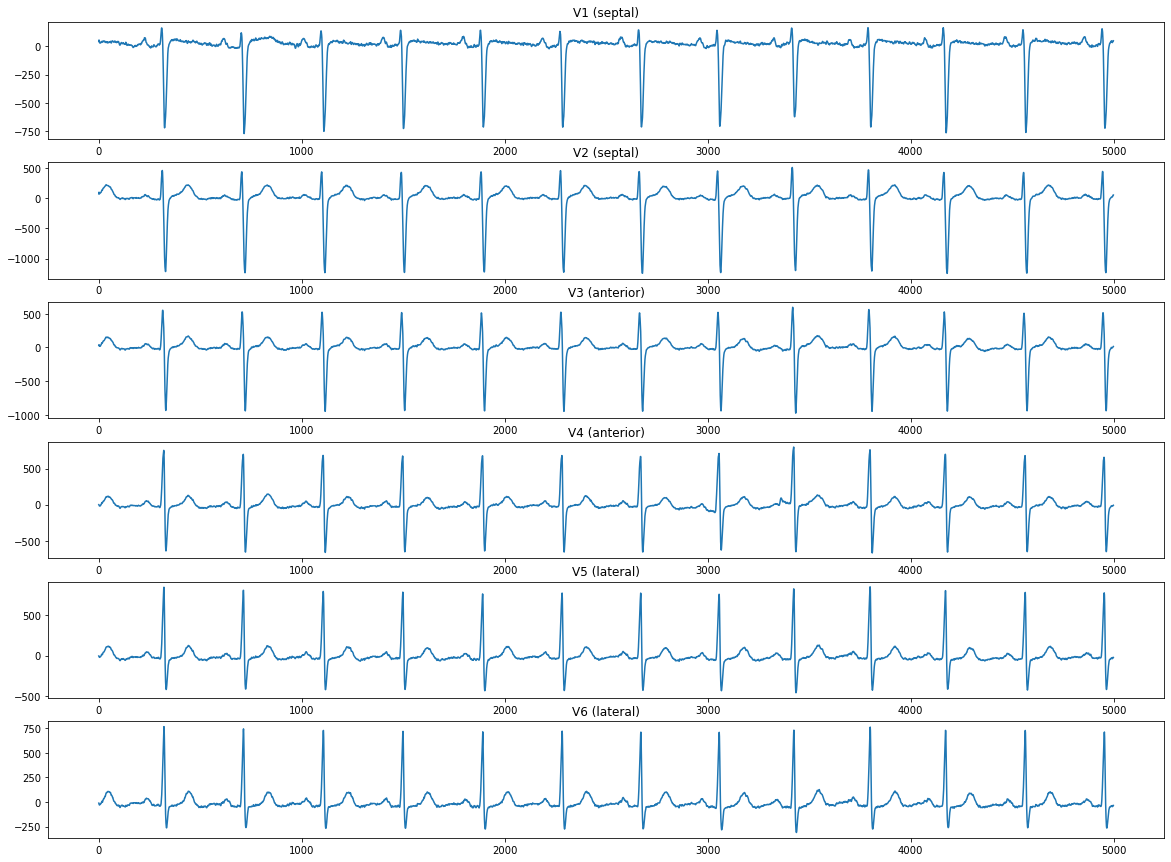

In [8]:
fig = plt.figure(figsize=(20, 15))
for i in range(6, 12):
    ax = fig.add_subplot(6, 1, i - 5)
    ax.plot(one_label_data_dict['Normal'][0][i])
    plt.title(lead_names[i])

plt.plot()
plt.show()

# Arrythmias
## AF - Atrial fibrillation
episodes of (or even continous) rapid and irregular beating of the atrial chambers
- irregular RR-Intervalls
- P-Wave often lost (flicker waves instead)

RR-Intervalls in lead II (ms):  [362.0, 374.0, 342.0, 380.0, 510.0, 406.0, 360.0, 406.0, 544.0, 544.0, 400.0, 324.0, 394.0, 518.0, 438.0, 518.0, 412.0, 332.0, 358.0, 418.0, 398.0, 378.0, 376.0, 358.0]
Standarad deviation (ms):  65.6099056714931


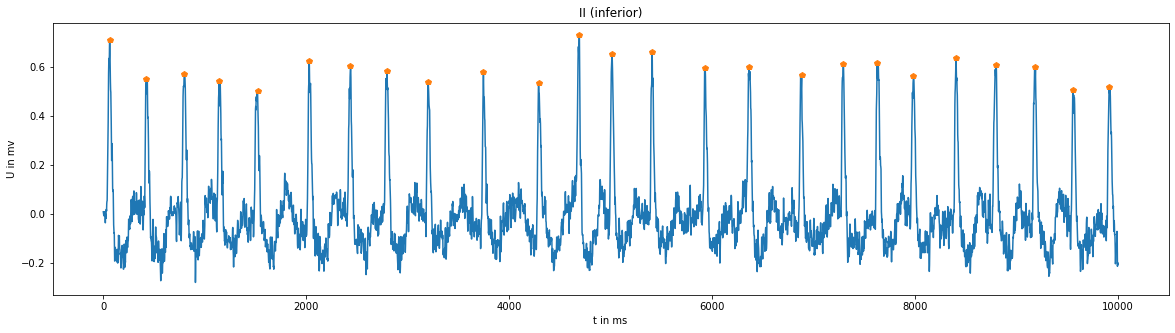

In [18]:
fig = plt.figure(figsize=(20, 5))
leads = [1]
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['AF'][0][l] / 1000 # 300:2600
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)
    
    idx, = bio.signals.ecg.hamilton_segmenter(voltage, sampling_rate=500.0) # detect_peaks from get_12ECG_features was not working properly
    ax.plot(idx / fq * 1000, voltage[idx], 'p')
    if l == 1:
        rr = [(idx[i] - idx[i-1]) / fq * 1000 for i in range(1, len(idx))]
        print('RR-Intervalls in lead II (ms): ', rr)
        print('Standarad deviation (ms): ', np.std(rr))

    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

plt.plot()
plt.show()

## I-AVB - First-degree atriventricular block
slower conduction of el. impulses from atrial chambers to ventricles through AV node

note: prolongation of PR-Intervall can be caused by medication, too
- PQ-Intervall > 200 ms
- P-Wave and T-Wave may overlay ( different quality of P-Qave in different leads, recomendation to check all leads)

PQ-Intervalls in lead II (ms):  [220.0, 220.0]


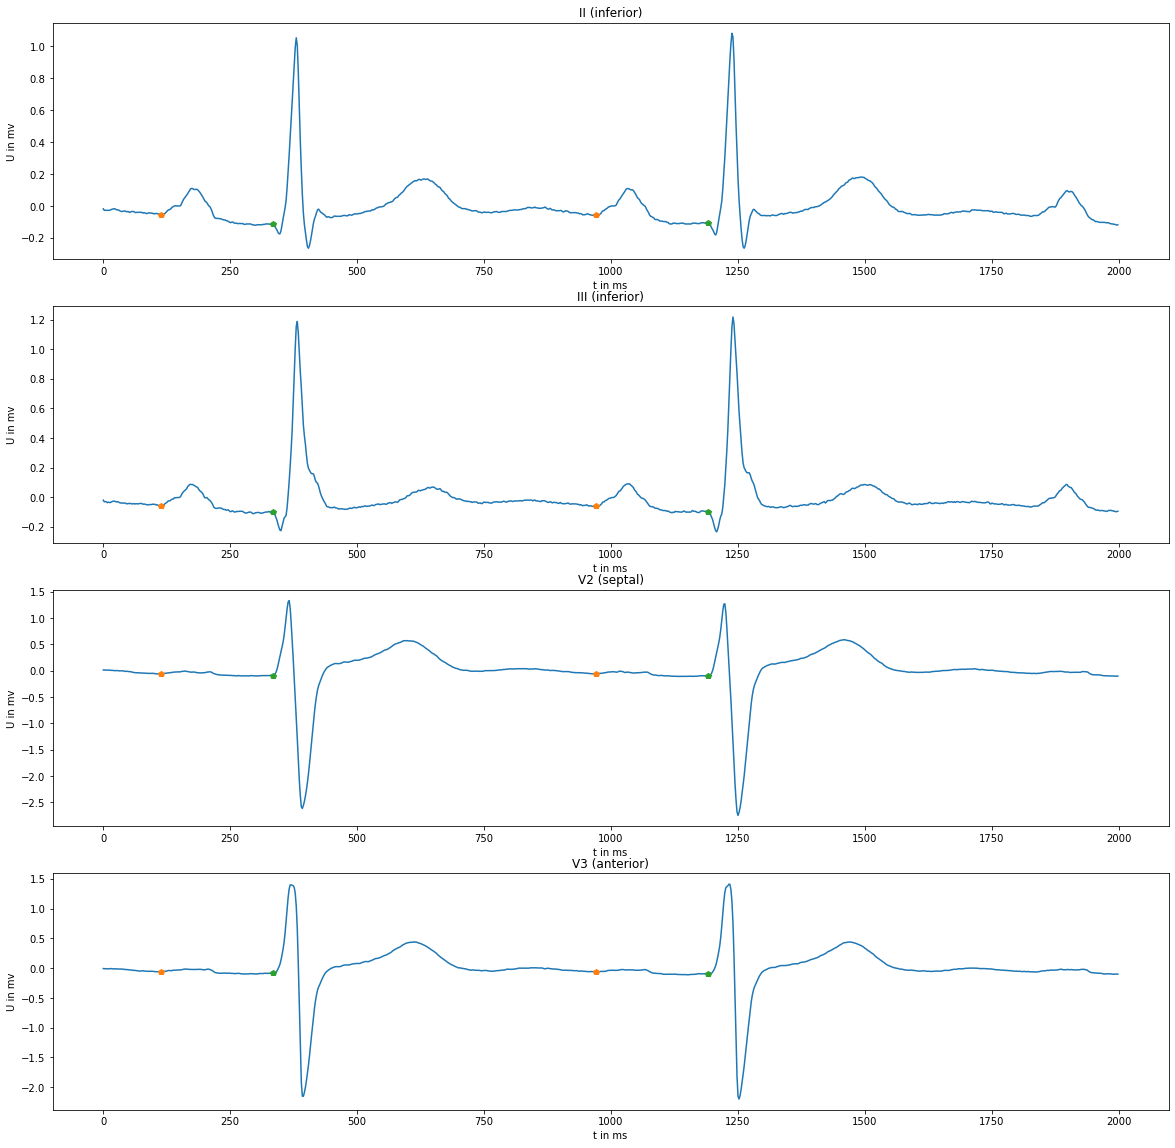

In [19]:
fig = plt.figure(figsize=(20, 20))
leads = [1, 2, 7, 8]
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['I-AVB'][0][l][:1000] / 1000
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)
    pqs = np.array([[57, 167], [485, 595]]) # for lead II
    ax.plot(pqs / fq * 1000, voltage[pqs], 'p')
    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])
print('PQ-Intervalls in lead II (ms): ', [(intervall[1] - intervall[0]) / fq * 1000 for intervall in pqs])
plt.plot()
plt.show()

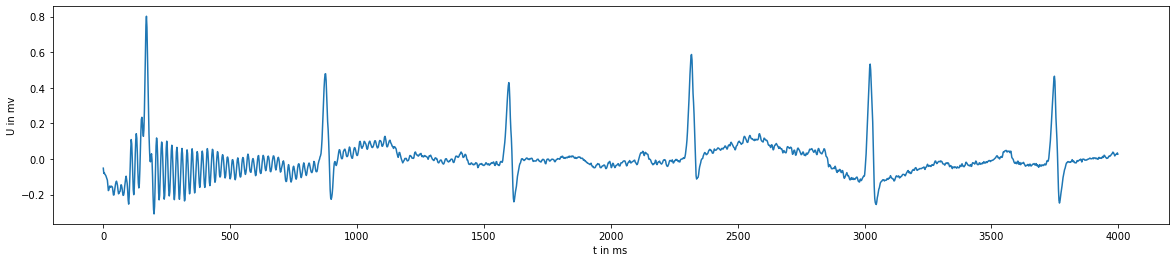

In [20]:
# overlaying P- and T-Wave, none found in 0 - 50
voltage = one_label_data_dict['I-AVB'][50][11][:2000] / 1000# 15
samples = np.arange(len(voltage))
time = samples / fq * 1000
fig = plt.figure(figsize=(20, 4))
plt.plot(time, voltage)
plt.xlabel('t in ms')
plt.ylabel('U in mv')
plt.show()

## LBBB - Left bundle branch block
left ventricle contracts delayed due to block in left bundle branch -> contracts later than right ventricle

rarely occurs without other pathologies

- QRS-Intervall >= 120 ms (must apply)
- I, V5, V6: no Q-Wave
- R-Peak - S > 60 ms
- notch in R-Peak in at least two of I, aVL, V1, V2, V5, V6 (especialy in V6)
- QS or rS complex in V1
- T wave should be directed opposite to QRS complex

QRS-Intervall (ms):  140.0


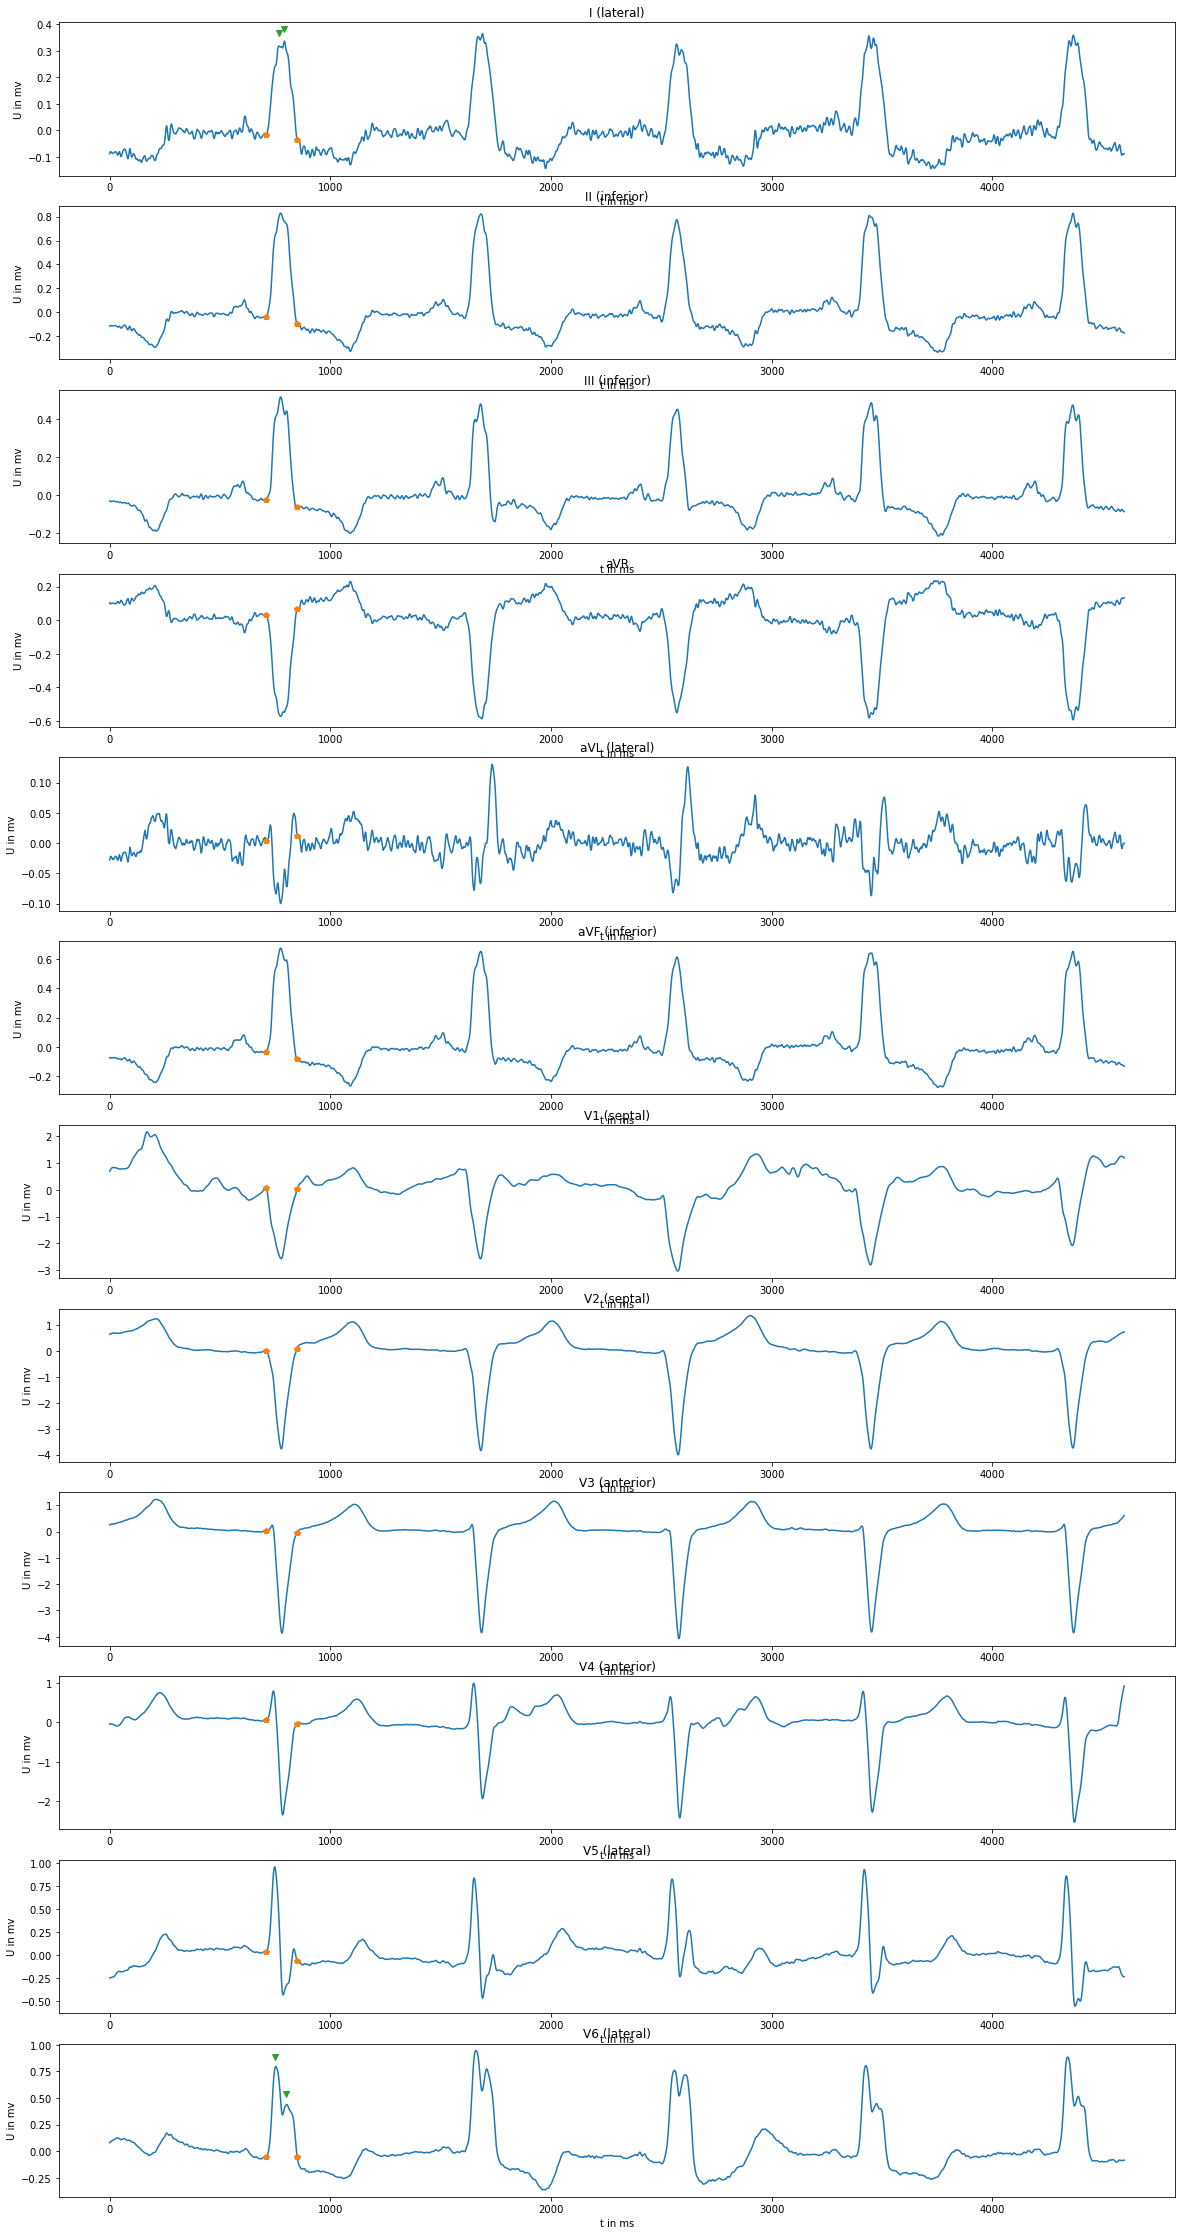

In [25]:
fig = plt.figure(figsize=(20, 40))
leads = np.arange(12)
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['LBBB'][0][l][300:2600] / 1000 # 300:2600
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)
    
    qrs = np.array([355, 425])
    ax.plot(qrs / fq * 1000, voltage[qrs], 'p')
    
    if l == 0:
        notch = np.array([383, 395])
        ax.plot(notch / fq * 1000, voltage[notch] + 0.05, 'v')
    elif l == 11:
        notch = np.array([375, 400])
        ax.plot(notch / fq * 1000, voltage[notch] + 0.1, 'v')

    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

print('QRS-Intervall (ms): ', (qrs[1] - qrs[0]) / fq * 1000)
plt.plot()
plt.show() 

## PAC - Premature artrial contraction / complex
premature heartbeats originating in the atrial chambers (rather than in sinatrial node)

occurs occasionally
- abnormally shaped and premature P wave
- shorter PR interval (still 120 to 200 ms)
- RR before and after ectopic beat added < 2RR normal beats (incomplete compensatory pause)-> next normal beat premature to regular rhythm without interuption by PAC
- RR beetween PAC and next beat is longer than normal RR
- normal or narrow QRS complex or not present (can be wide if theres RBBB or LBBB)

RR-Intervalls in lead II (ms):  [730.0, 726.0, 726.0, 736.0, 494.0, 964.0, 794.0, 728.0, 718.0, 720.0, 718.0, 722.0]


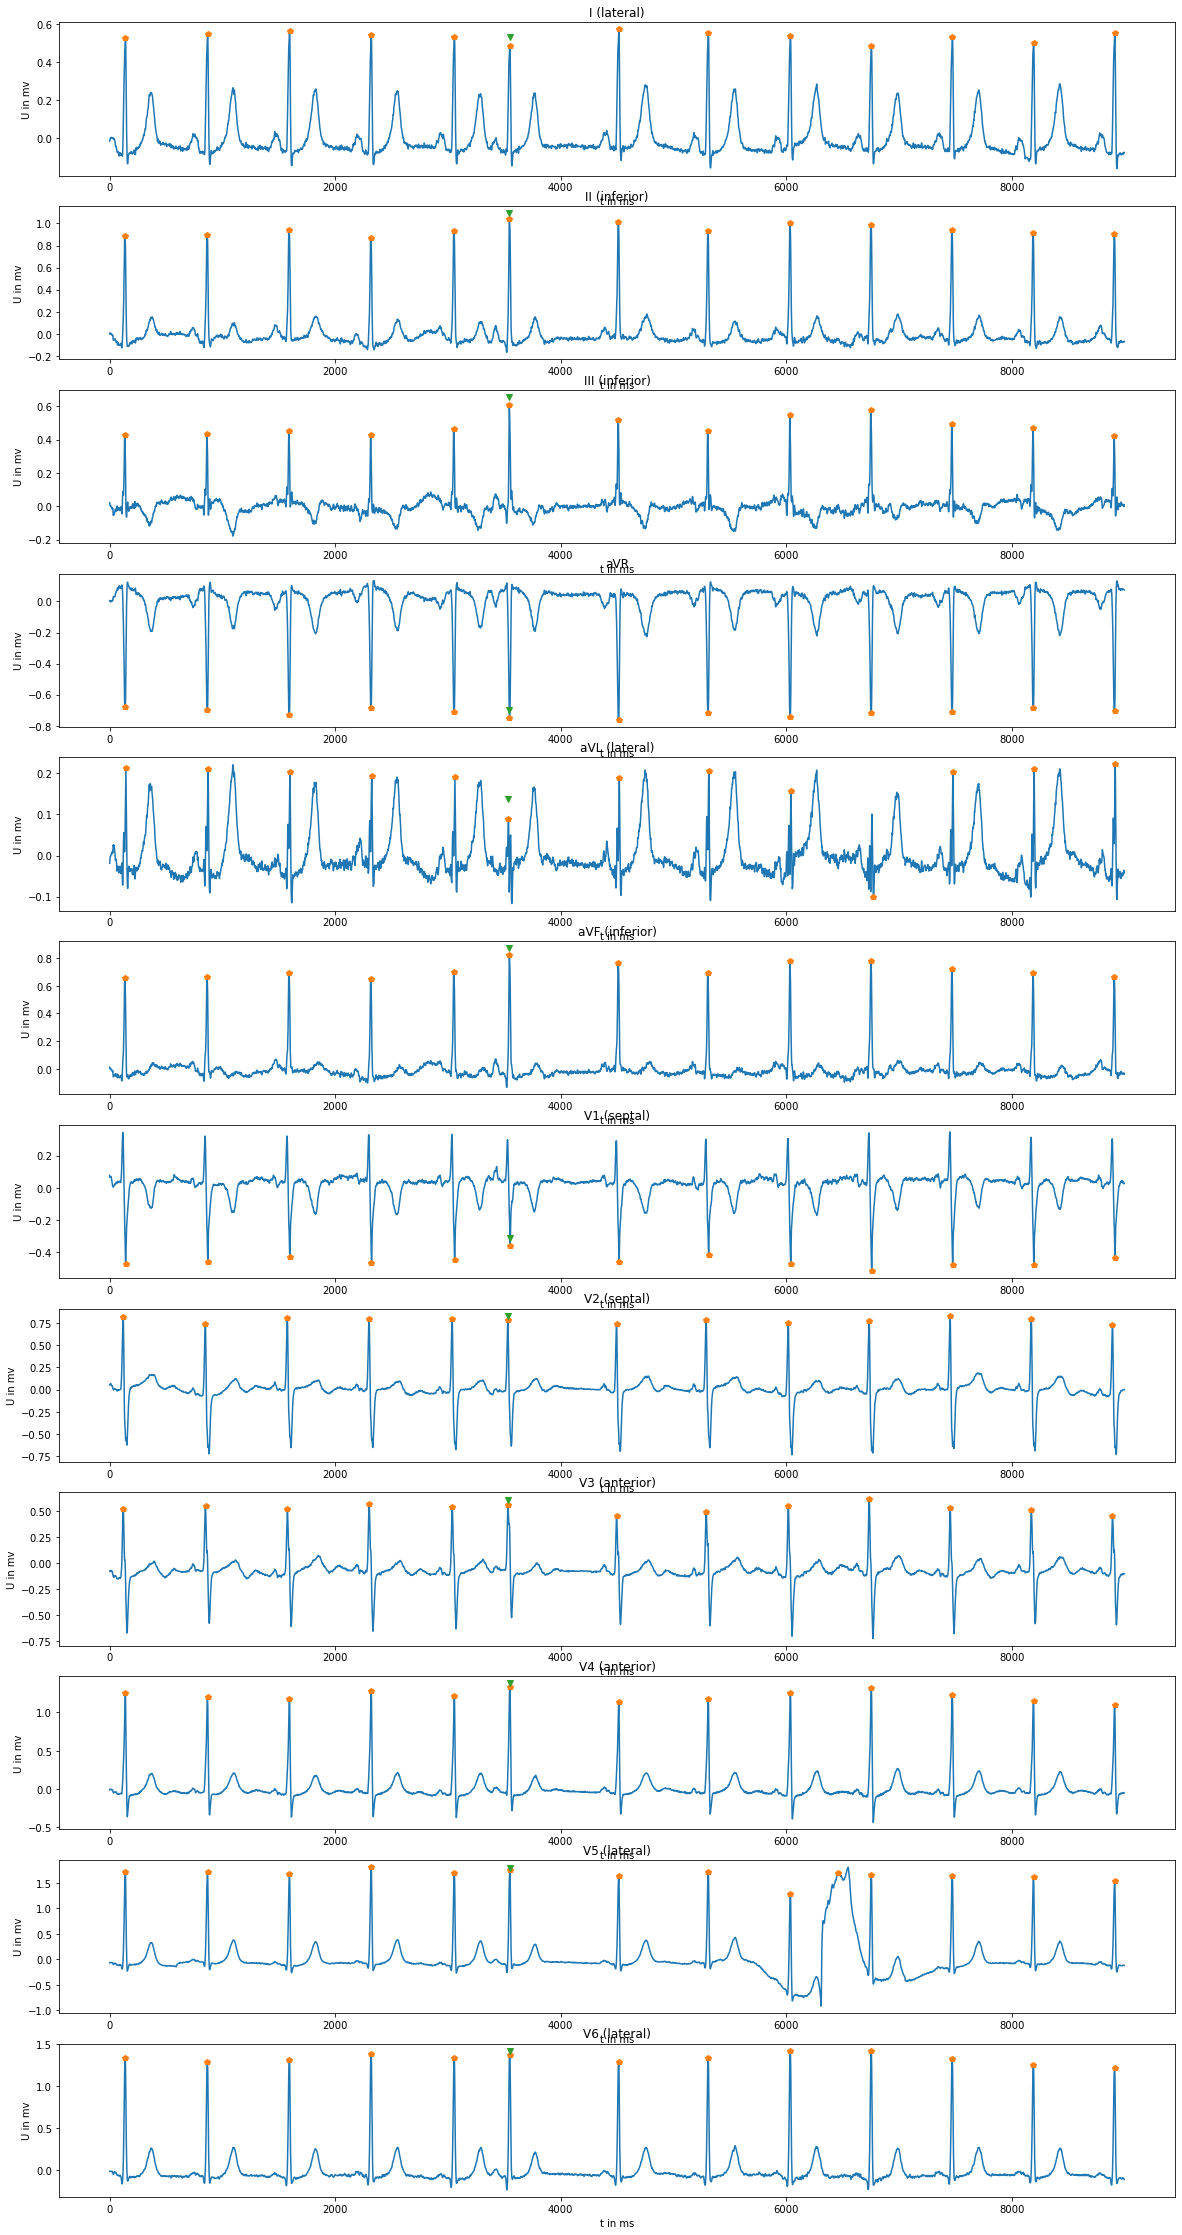

Mean (ms):  731.3333333333334
Median (ms):  726.0


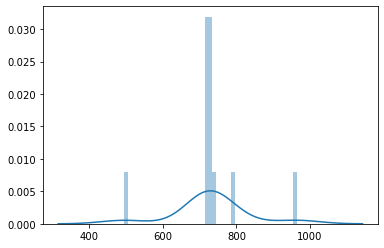

In [33]:
fig = plt.figure(figsize=(20, 40))
leads = np.arange(0, 12)
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['PAC'][0][l][2500:7000] / 1000
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)
    
    idx, = bio.signals.ecg.hamilton_segmenter(voltage, sampling_rate=500.0) # detect_peaks from get_12ECG_features was not working properly
    ax.plot(idx / fq * 1000, voltage[idx], 'p')
    ax.plot(idx[5]/ fq * 1000, voltage[idx[5]] + 0.05, 'v')

    if l == 1:
        rr = [(idx[i] - idx[i-1]) / fq * 1000 for i in range(1, len(idx))]
        print('RR-Intervalls in lead II (ms): ', rr)

    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

plt.plot()
plt.show()

sns.distplot(rr)
print('Mean (ms): ', np.mean(rr))
print('Median (ms): ', np.median(rr))

## PVC - Premature ventricular complex
premature heartbeats originating in Purkinje fibers in the ventricles (normaly in sinoatrial node)

can occour ocassionaly or as bigeminy (PVC every ohter beat), trigeminy etc.
- intervall from PVC to next normal beat is prolonged (compensatory pause)
- no proceding P wave associated with PVC (since it doesnt orignate in atrial chambers)
- compensatory pause is longer than in PAC
- different appearance of QRS: wide and bizarre; >= 120 ms
- ST-T segemnt oriented oppositely to QRS complex
- 2RR form proceding regular beat to next regular beat (due to complete compensatory pause)

RR-Intervalls in lead II (ms):  [642.0, 1104.0, 650.0]
Mean (ms):  798.6666666666666


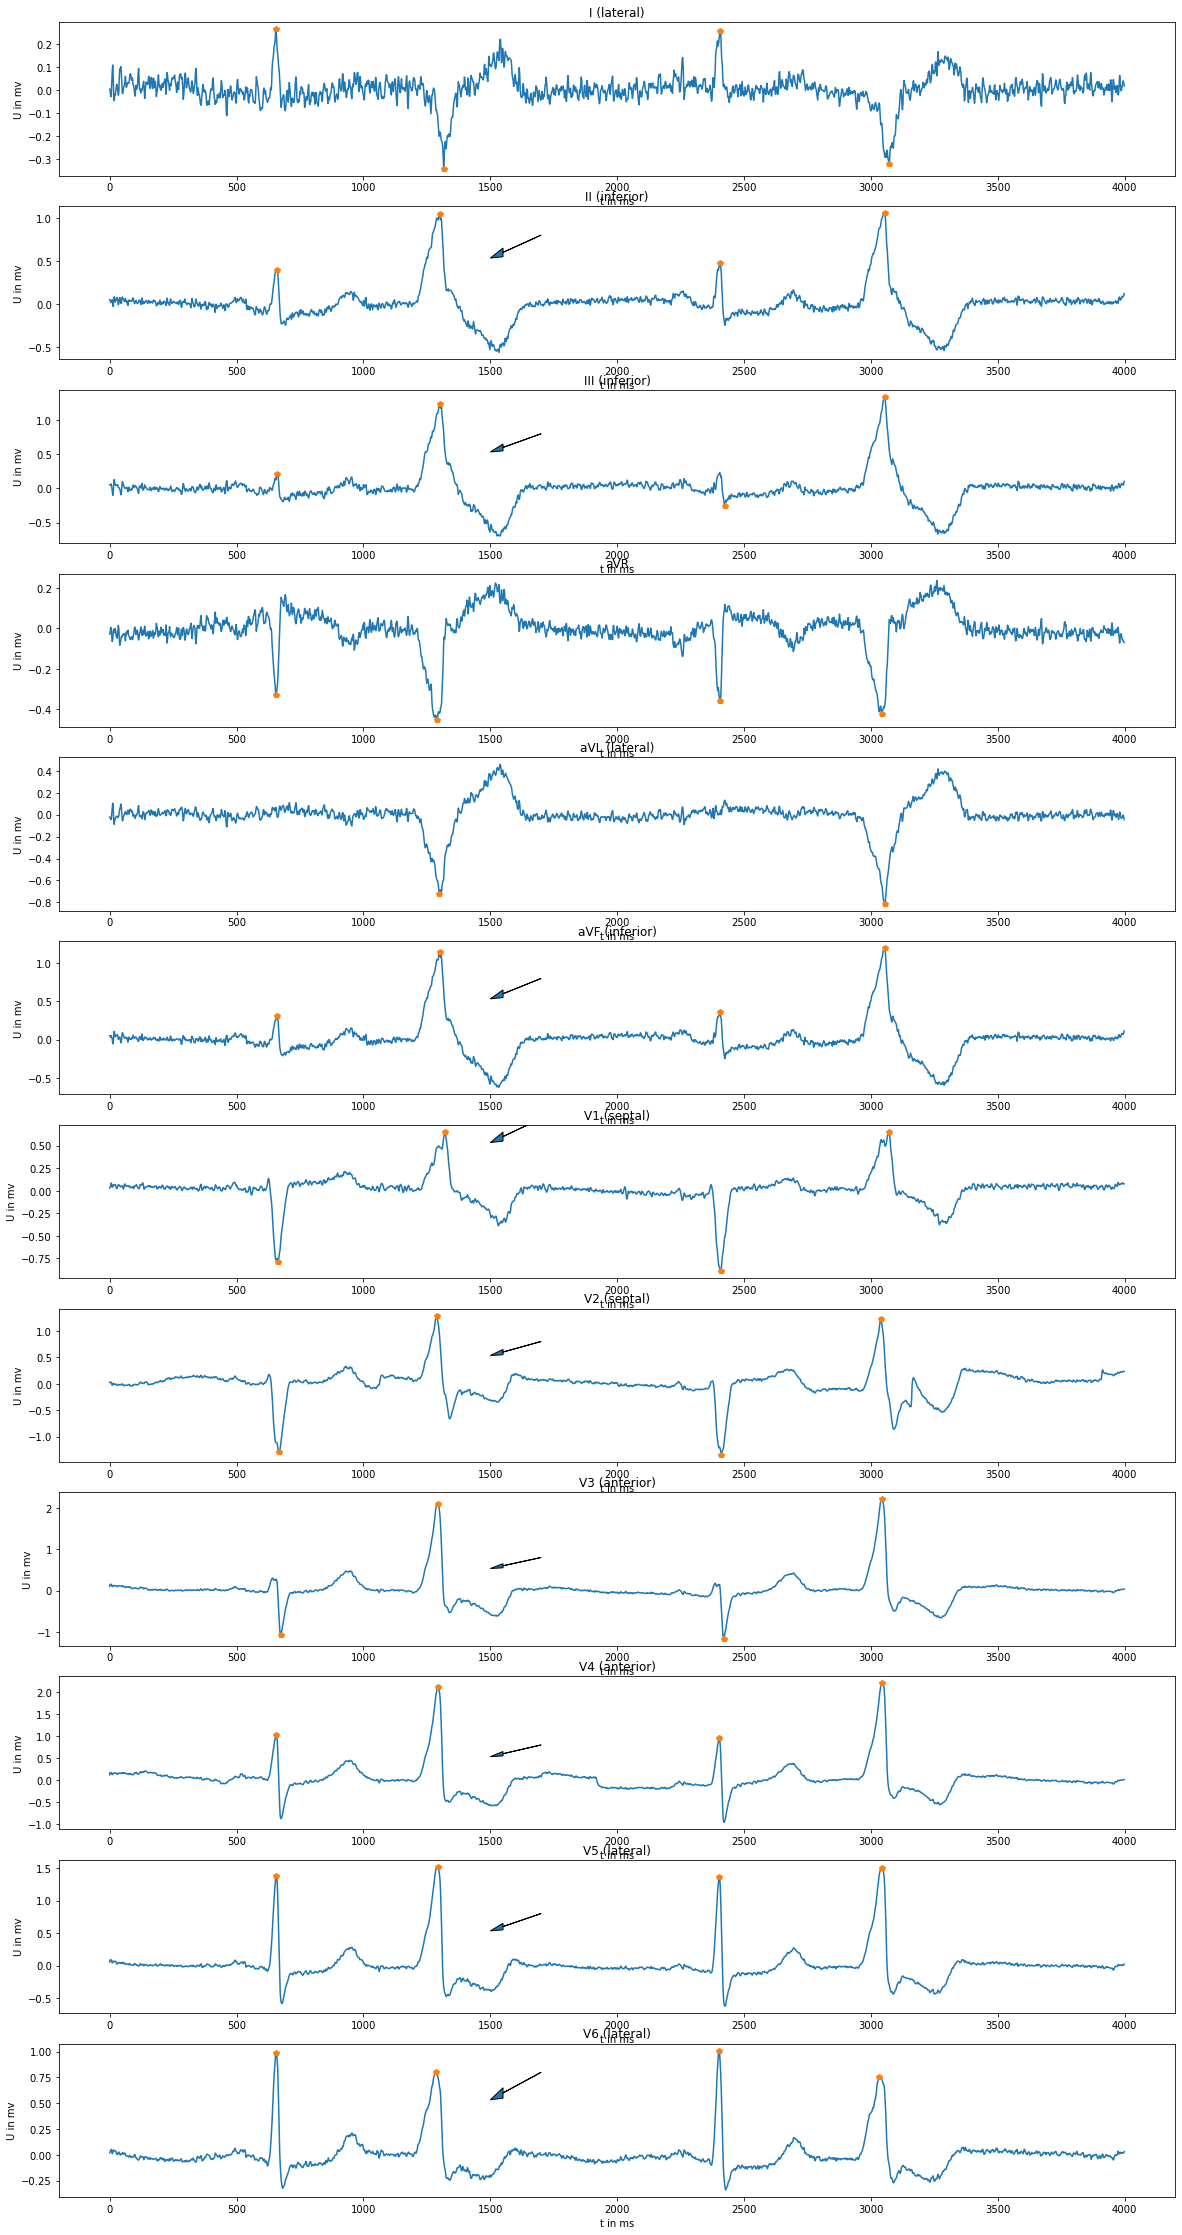

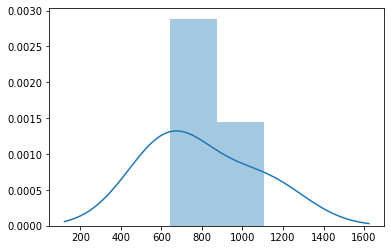

In [48]:
fig = plt.figure(figsize=(20, 40))
leads = np.arange(0, 12)
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['PVC'][1][l][:2000] / 1000
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)
    
    idx, = bio.signals.ecg.hamilton_segmenter(voltage, sampling_rate=500.0) # detect_peaks from get_12ECG_features was not working properly
    ax.plot(idx / fq * 1000, voltage[idx], 'p')
    plt.arrow(1700, 0.8, -150, -0.2, head_width=0.1, head_length=50)
    
    if l == 1:
        rr = [(idx[i] - idx[i-1]) / fq * 1000 for i in range(1, len(idx))]
        print('RR-Intervalls in lead II (ms): ', rr)
        print('Mean (ms): ', np.mean(rr))

    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

plt.plot()
plt.show() 

sns.distplot(rr)

## RBBB - Right bundle branch block
no conduction of right ventricle through Bundle of His-Purkinje fibres due to a block -> slower conduction through myocardium
- QRS-Intervall >= 120 ms (100 ms for incomplete block)
- second R-Peak in V1, V2 (rsR' / 'M-Configuration')
- beginn of QRS - R-Peak (R') > 50 ms for V1
- big and/or prolonged ('slurred') S-Wave in I, V6 (also aVF V5)
- T wave should be directed opposite to terminal deflection of QRS complex

QRS-Intervall (ms):  106.0


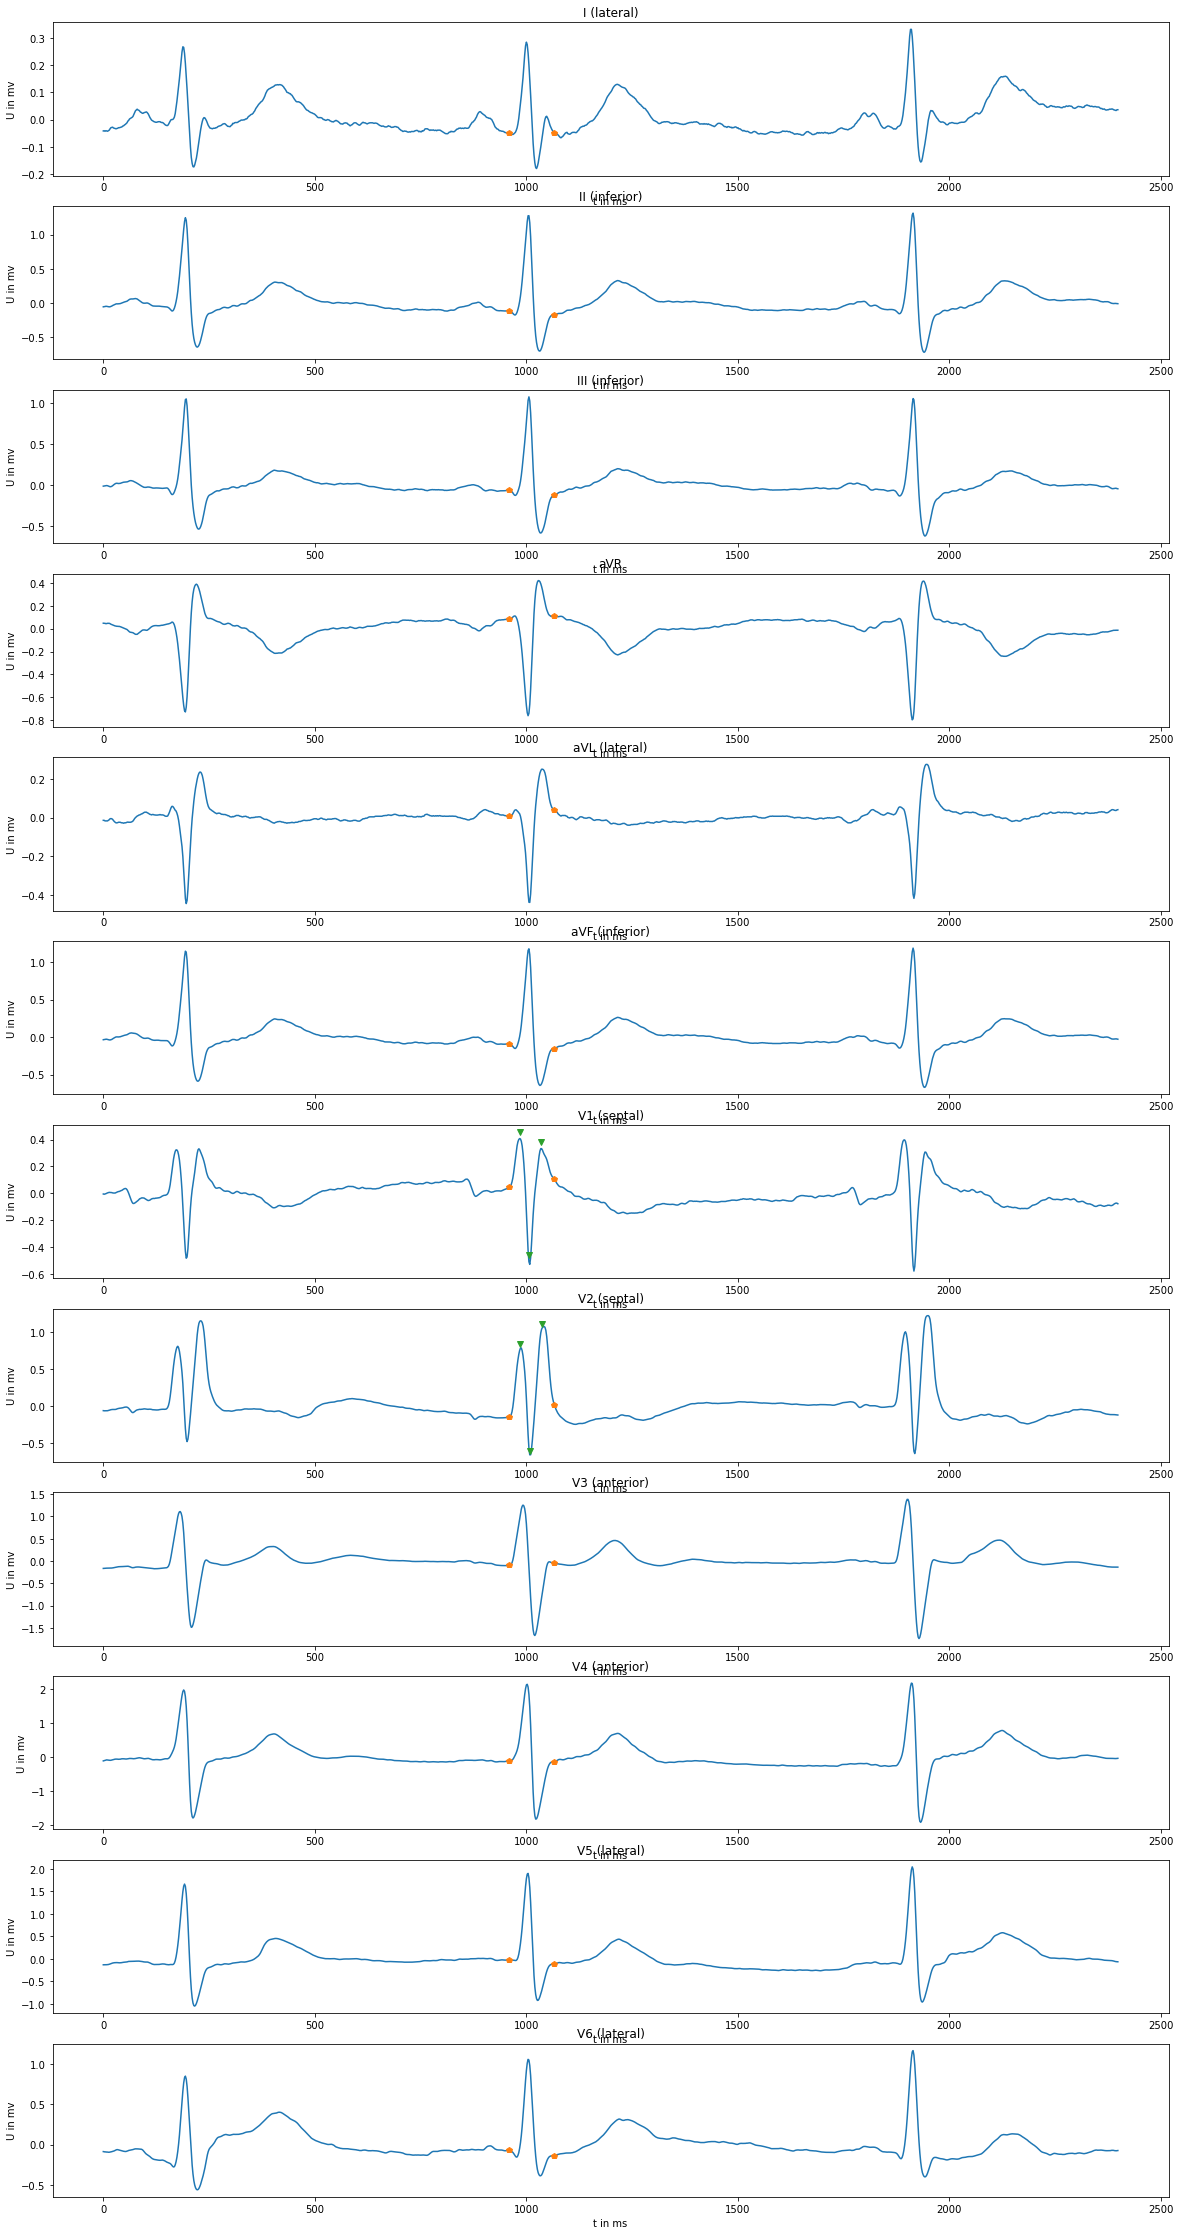

In [50]:
fig = plt.figure(figsize=(20, 40))
leads = np.arange(12)
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['RBBB'][1][l][300:1500] / 1000 # 300:2600
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)
    
    qrs = np.array([480, 533]) #480, 533
    ax.plot(qrs / fq * 1000, voltage[qrs], 'p')
    
    if l == 6:
        rsR = np.array([492, 503, 517])
        ax.plot(rsR / fq * 1000, voltage[rsR] + 0.05, 'v')
    elif l == 7:
        rsR = np.array([493, 504, 519])
        ax.plot(rsR / fq * 1000, voltage[rsR] + 0.05, 'v')

    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

print('QRS-Intervall (ms): ', (qrs[1] - qrs[0]) / fq * 1000) # 106 ms is too short
plt.plot()
plt.show() 

## STD - ST-segment depression

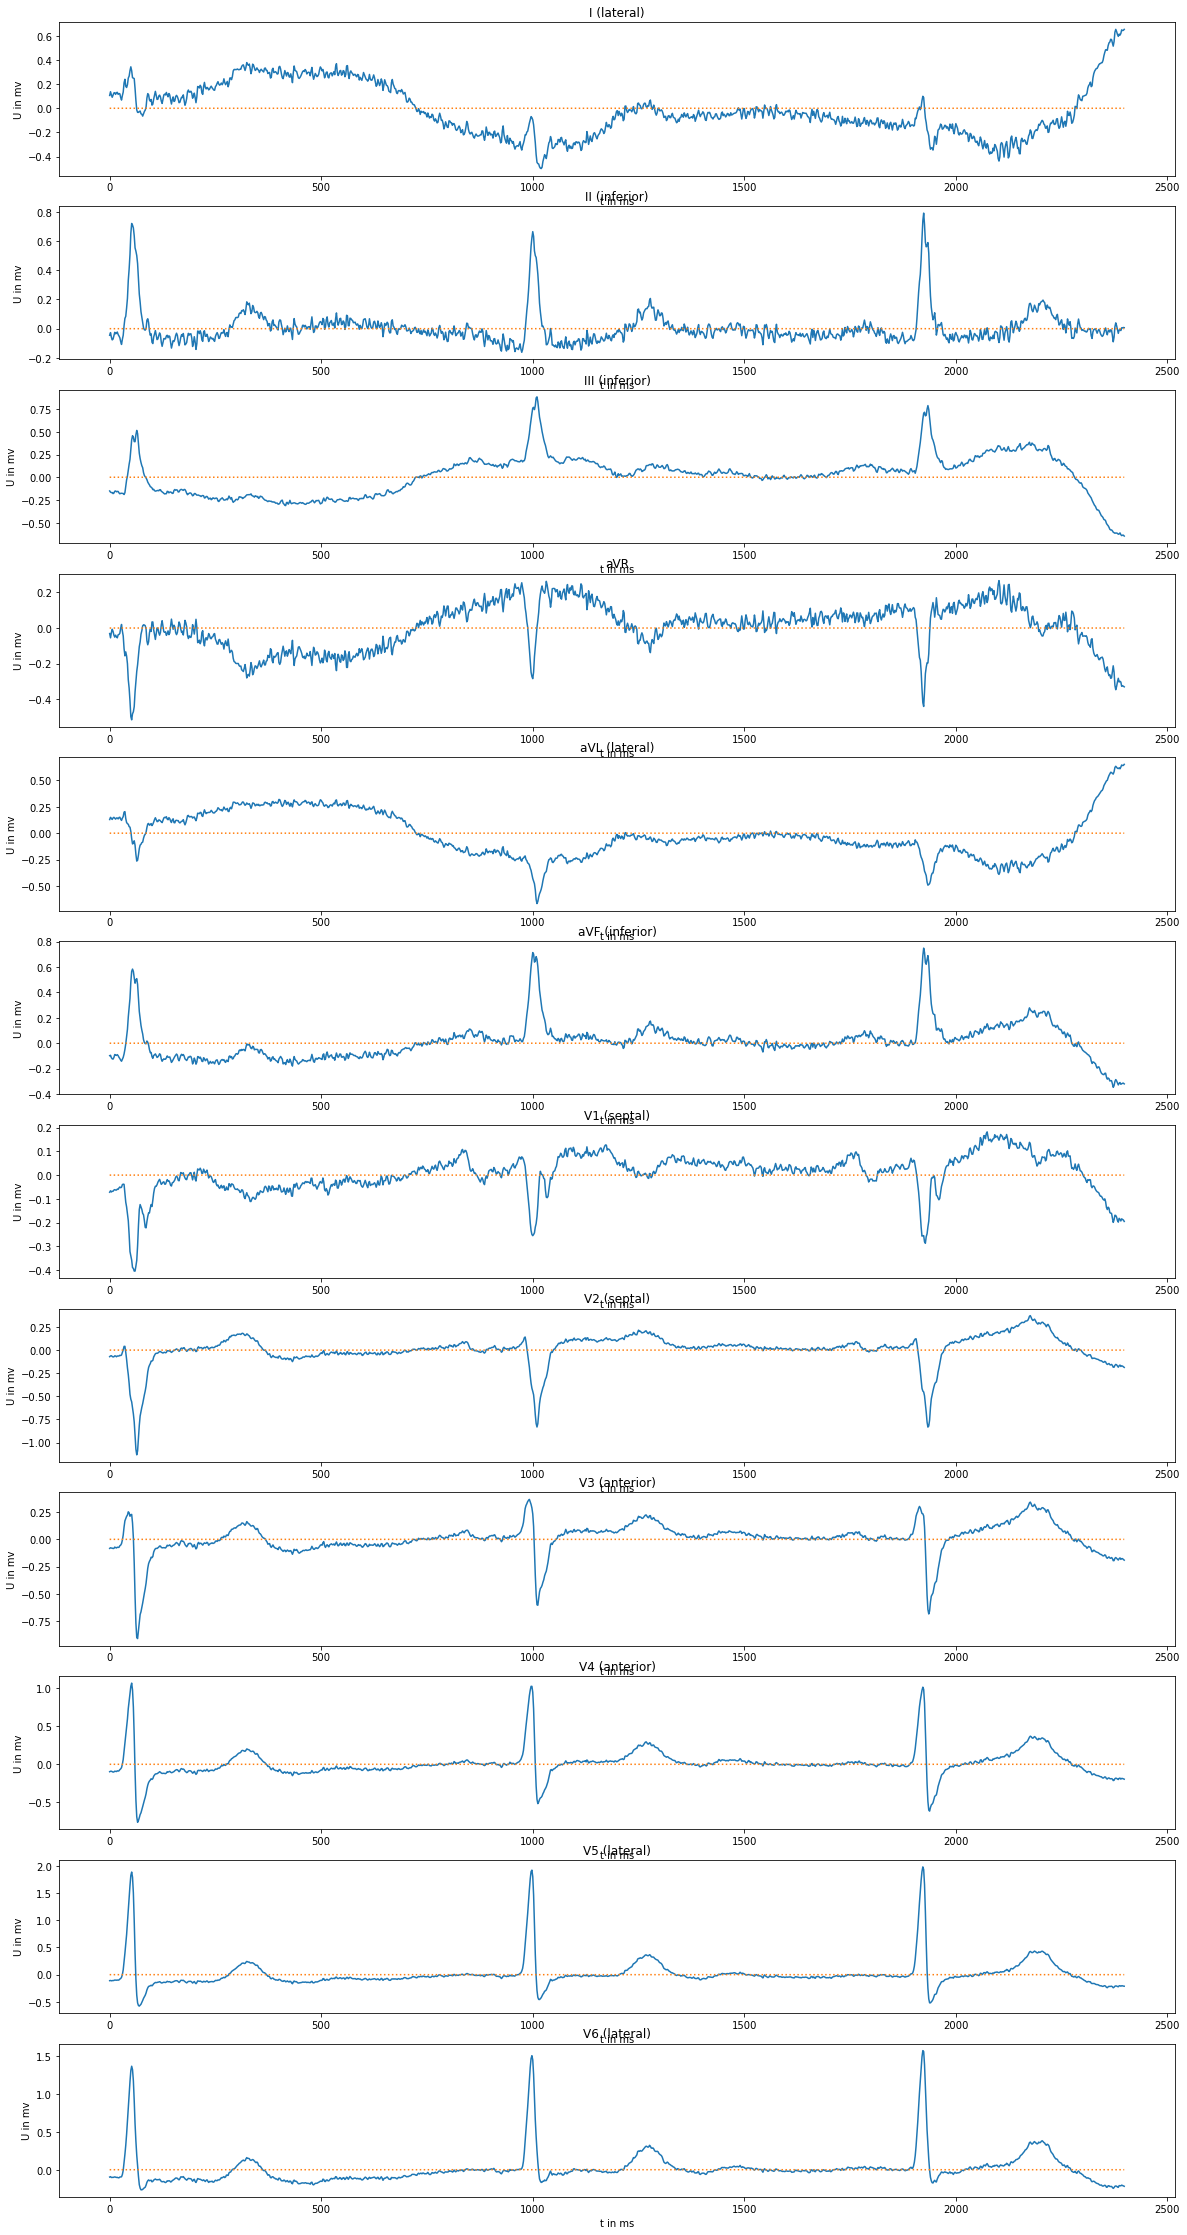

In [51]:
# normal ST-segment: between -0,05 mv and 0,1 mV parallel to baseline
fig = plt.figure(figsize=(20, 40))
leads = np.arange(12)
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['STD'][2][l][300:1500] / 1000# correction of baseline required (bias, bandpass filter?)
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)

    baseline = np.zeros(len(time))
    ax.plot(time, baseline, ':')
    
    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

plt.plot()
plt.show() 

## STE - ST-segment elevation

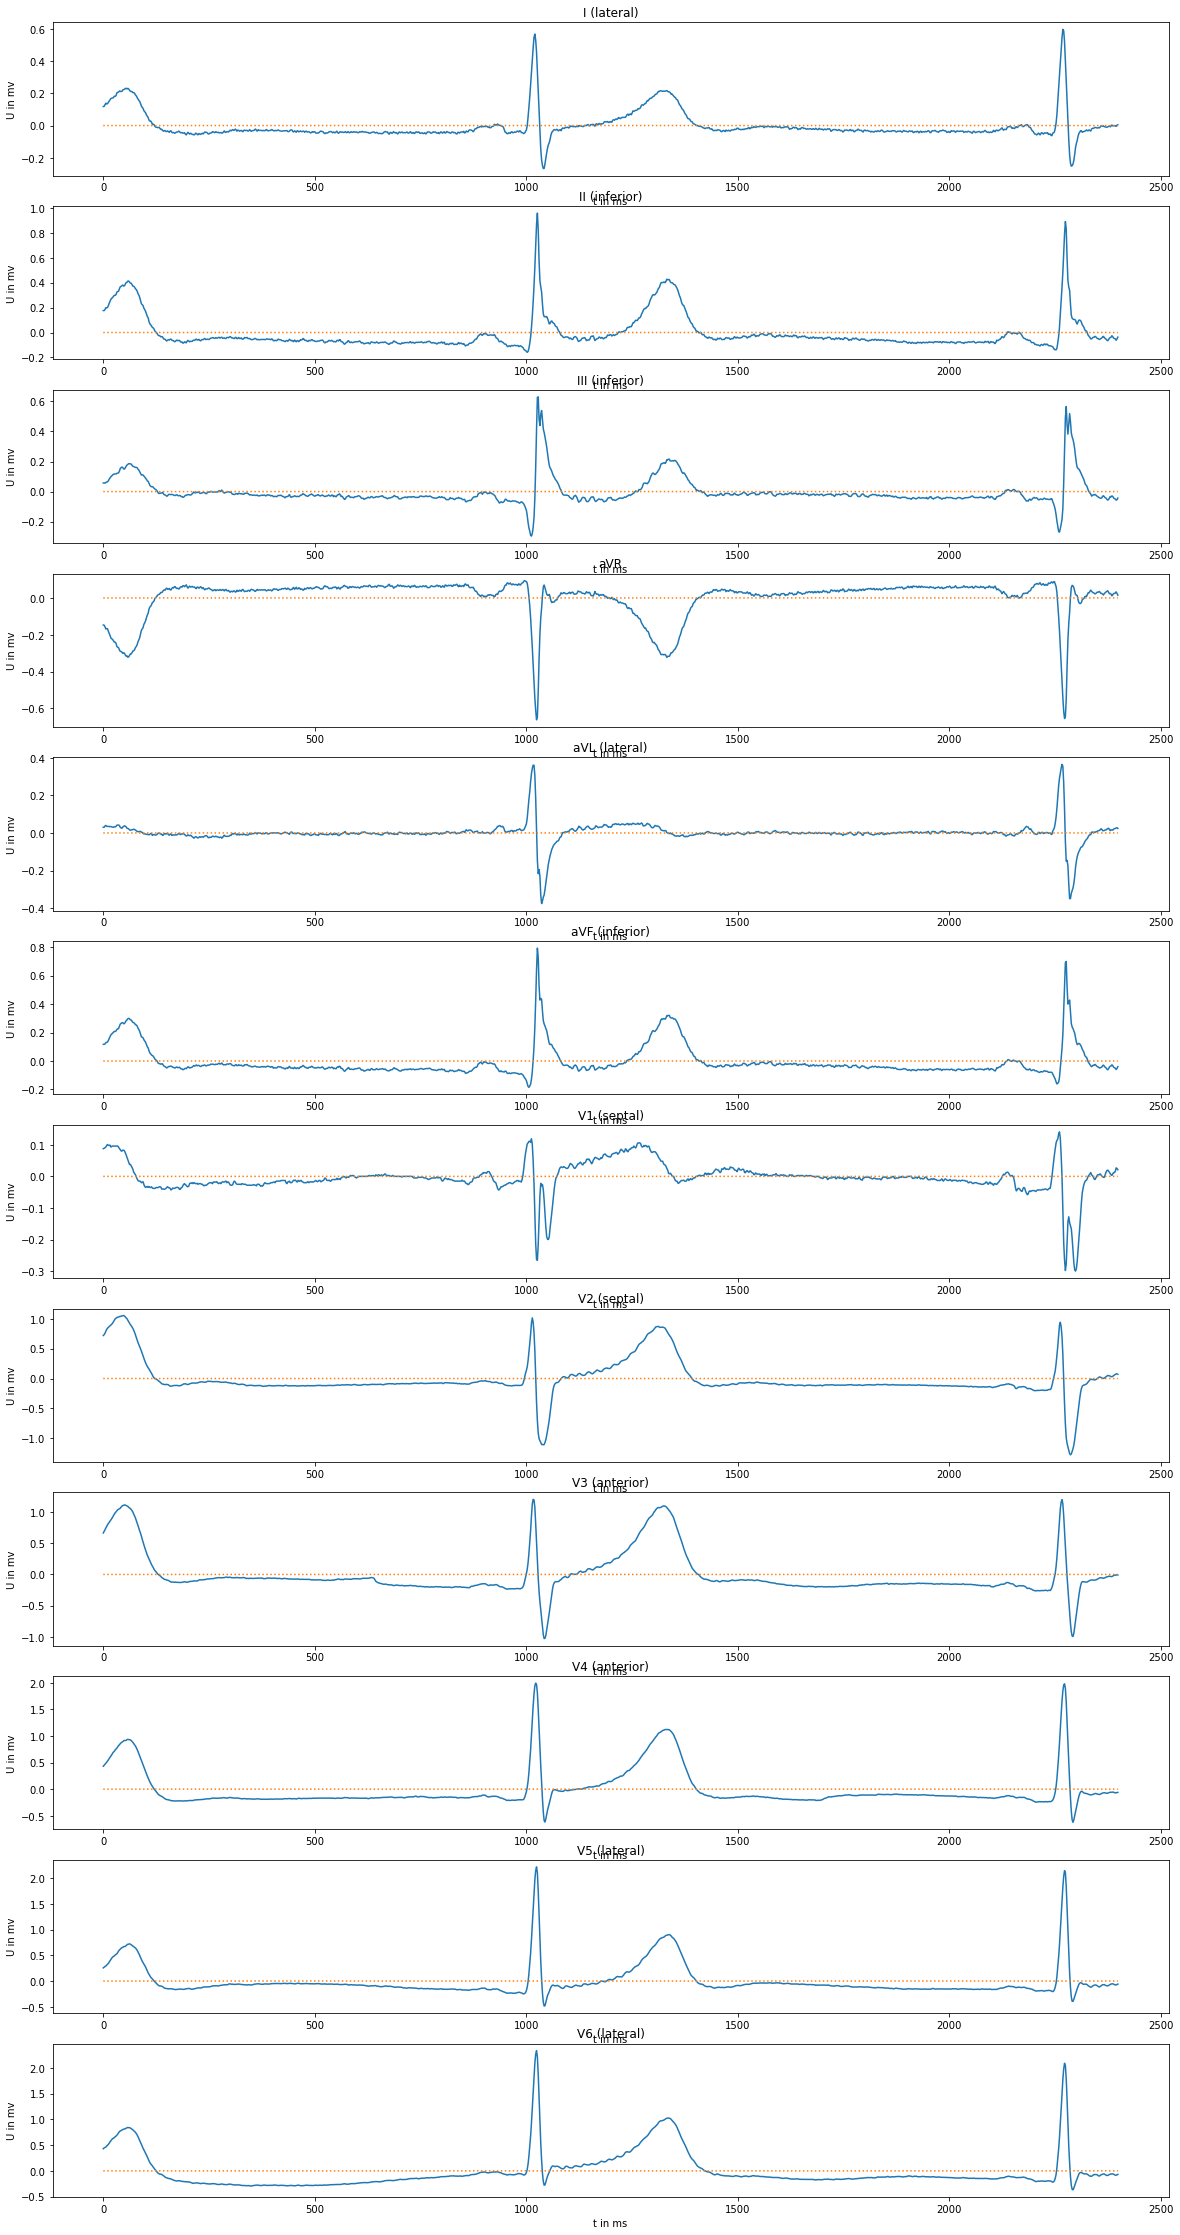

In [52]:
# normal ST-segment: between -0,05 mv and 0,1 mV parallel to baseline
fig = plt.figure(figsize=(20, 40))
leads = np.arange(12)
for i, l in enumerate(leads):
    ax = fig.add_subplot(len(leads), 1, i + 1)
    voltage = one_label_data_dict['STE'][4][l][300:1500] / 1000 # correction of baseline required (bias, bandpass filter?)
    samples = np.arange(len(voltage))
    time = samples / fq * 1000
    ax.plot(time, voltage)

    baseline = np.zeros(len(time))
    ax.plot(time, baseline, ':')
    
    plt.xlabel('t in ms')
    plt.ylabel('U in mv')
    plt.title(lead_names[l])

plt.plot()
plt.show() 